# Water Potability (음수) 가능 여부를 판단하기 문제 해결

- 주요 요소 
    - 데이터 분석(EDA)
    - 결측 데이터 처리
    - 피처 엔지니어링
    - 머신러닝, 모델 평가, 테스트
    - 사용 학습기 : KNN, xgboost ML 모델을 만들고 성능 비교하기
    - GridSearchCV : 최적의 하이퍼 파라미터를 찾을 때 사용함

In [1]:
# warning 무시
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
# '-' 깨짐 해결 모듈
import matplotlib as mpl

# 한글 폰트 설정
import platform

from matplotlib import rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Linux':
    rc('font', family = 'NanumGothic')  # 또는 '나눔고딕'
    print('Linux system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')
    


Linux system... font set to NanumGothic


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 데이터 설명

- ph: pH 1. 물(0~14).량
- Hardness : 비누를 침전시키는 물의 용량(mg/L)L.
- Solid : 총 용해 고형물(ppm)pm.
- Chloramin : 클로라민의 양(ppm).ppm.
- Sulfmg/L : 단위로 용해된 황산염의 양.mg/L.
- Conducti : 물의 전기 전도도(단위: μS/cm).μS/cm.
- Organic_c : 유기 탄소의 양(ppm).in ppm.
- Trihalomeμg/L : 단위의 트리할로메탄 양.in μg/L.
- Tu NTU : 단위로 물의 발광 특성을 측정함.r in NTU.
- Po : 물이 인간이 섭취하기에 안전한지 여부를 나타냄

마실 수 있는 -> 1

마실 수 없는 -0potable -> 0

사용할 데이터는 사람이 마실 수 있는 물인지 아닌지를 판단하는 데이터 입니다.

독립변수(X) : ph ~ Turbidity
종속변수(y) : potability


In [4]:
water_df = pd.read_csv("datas_ml/water_potability.csv")
water_df.tail()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.177061,7.509306,NaN,327.459760,16.140368,78.698446,2.309149,1


In [5]:
water_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


> 모두 숫자형 데이터라는 것을 판단하였고 전체 데이터 개수와 potability의 개수가 동일 (즉 음수 가능에 대해서는 결측치가 없음)하기에 그 외의 다른 feature 의 결측치를 보완해야 한다는 것을 깨닫게 됨 

In [27]:
water_df[['ph','Sulfate','Trihalomethanes']].isnull().sum()

ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64

In [28]:
water_df[['ph','Sulfate','Trihalomethanes']].describe()

,ph,Sulfate,Trihalomethanes
count,2785.000000,2495.000000,3114.000000
mean,7.080795,333.775777,66.396293
std,1.594320,41.416840,16.175008
min,0.000000,129.000000,0.738000
25%,6.093092,307.699498,55.844536
50%,7.036752,333.073546,66.622485
75%,8.062066,359.950170,77.337473
max,14.000000,481.030642,124.000000


> NaN 값을 가진 ph, Sulfate, Trihalomethanes 열 모두 평균값으로 대체하면 될 것 같다고 판단

In [29]:
wdphm = water_df['ph'].mean()
water_df['ph'] = water_df['ph'].fillna(wdphm)

wdsm = water_df['Sulfate'].mean()
water_df['Sulfate'] = water_df['Sulfate'].fillna(wdsm)

wdtm = water_df['Trihalomethanes'].mean()
water_df['Trihalomethanes'] = water_df['Trihalomethanes'].fillna(wdtm)

In [30]:
water_df[['ph','Sulfate','Trihalomethanes']].isnull().sum()

ph                 0
Sulfate            0
Trihalomethanes    0
dtype: int64

In [32]:
water_df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1


> 결측치를 처리하였으니 현재 각 feature 의 값이 제각기 너무 산발적이고 큰 것을 감안해서 feature scaling 을 진행

*많이 사용하는 표준화 방식으로 진행*

In [31]:
from sklearn.preprocessing import StandardScaler

In [33]:
water_df_x = water_df.drop('Potability', axis = 1)
water_df_y = water_df['Potability']

In [36]:
water_df_x.head()
water_df_y.head()

0    0
1    0
2    0
3    0
4    0
Name: Potability, dtype: int64

In [39]:
scaler = StandardScaler()
water_scaled = scaler.fit_transform(water_df_x)

type(water_scaled)

numpy.ndarray

### 머신러닝, 모델평가, 테스트

> KNN, XGBoost 모델 사용하기

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    water_scaled, water_df_y, 
    test_size=0.25, 
    random_state=42
)


In [41]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2457, 9), (819, 9), (2457,), (819,))

> KNN 모델을 이용하여 학습 및 테스트 진행

In [42]:
from sklearn.neighbors import KNeighborsClassifier

In [43]:
classifier = KNeighborsClassifier(n_neighbors=5) # 기본값 사용

In [44]:
classifier.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [47]:
y_pred_knn = classifier.predict(X_test)
y_pred_knn[:10]

array([0, 0, 0, 0, 0, 1, 0, 0, 1, 0])

In [48]:
from sklearn.metrics import classification_report, accuracy_score

print("정확도:", accuracy_score(y_test, y_pred_knn))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(y_test, y_pred_knn))

정확도: 0.6214896214896215

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.67      0.76      0.71       510
           1       0.50      0.39      0.44       309

    accuracy                           0.62       819
   macro avg       0.59      0.58      0.58       819
weighted avg       0.61      0.62      0.61       819



> 해당 데이터에서는 마실 수 있는 물을 얼마나 잘 맞춰내는지가 중요하기 때문에 "재현율(recall)" 값이 중요하다.

: 마실 수 있는 == 1 에 대한 recall 값이 0.39 로 매우 낮은 수준으로 판단된다..

> 다음 XGBoost 모델을 이용하여 학습 및 테스트 진행

In [50]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [51]:
xgb = XGBClassifier()

In [56]:
# xgboost의 best param을 찾기위한 grid map 정의

# 학습의 하이퍼파마리터 경우의 수 맵

# 기존에 진행했던 8번 주피터 노트북에서 실험 1번, 더 많은 학습 횟수의 grid map 정의 이용 

cv_params = {   # 학습 횟수 : 2 * 5 * 3 * 2 * 2 * 3 * cv=5 
    'booster': ['dbtree', 'dart'],
    'n_estimators': [100, 200, 300, 400, 500],   
    'max_depth': [3, 5, 7, 10, 15],               
    'gamma': [0, 1, 2, 3],                      
    'colsample_bytree': [0.8, 0.9],       
    'learning_rate': [0.01, 0.05, 0.1, 0.15] # boosting 이기에 경사하강함 -> 경사하강 rater 필요
}

In [57]:
grid_cv = GridSearchCV (

    xgb, param_grid = cv_params, cv=5, scoring = 'recall', # 재현율로 평가, 
    n_jobs = -1 
   
)

In [58]:
grid_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'booster': ['dbtree', 'dart'], 'colsample_bytree': [0.8, 0.9], 'gamma': [0, 1, ...], 'learning_rate': [0.01, 0.05, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True

In [61]:
# best f1_macro 수치와 best parameter확인
print(f"Best score of paramter search is: {grid_cv.best_estimator_}") # 최적의 하이퍼파라미터로 학습한 학습기
print(f"Best score of paramter search is: {grid_cv.best_score_:.10f}") # 그때의 점수 (recall)
print(f"Best param : {grid_cv.best_params_}") # 그때의 파라미터

Best score of paramter search is: XGBClassifier(base_score=None, booster='dart', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.15, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=15,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)
Best score of paramter search is: 0.4364830939
Best param : {'booster': 'dart', 'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.15, 'max_depth': 15, 'n_estimators': 500}


In [60]:
from sklearn.metrics import roc_auc_score

In [62]:
y_pred_xgb = grid_cv.predict(X_test)
y_pred_xgb[:10]


print("정확도:", accuracy_score(y_test, y_pred_xgb))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(y_test, y_pred_xgb))

roc_auc = roc_auc_score(y_test, y_pred_xgb)
print(f"grid_cv roc_auc : {roc_auc}")

정확도: 0.6507936507936508

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.69      0.79      0.74       510
           1       0.55      0.43      0.48       309

    accuracy                           0.65       819
   macro avg       0.62      0.61      0.61       819
weighted avg       0.64      0.65      0.64       819

grid_cv roc_auc : 0.6067294879116695


> 정확도 값이 비슷하지만 0.02p 높고 마실 수 있는 물 == 1 에 대한 재현율은 0.43 으로 knn 모델에 비해 더 우수한 모델로 평가된다.

**다만 런타임이 거의 2분에 가까웠다..**

In [ ]:
from xgboost import plot_importance
from matplotlib import pyplot

# numpy 배열의 컬럼명을 명명하기 위한 방법 

booster = grid_cv.best_estimator_.get_booster() 
booster.feature_names = list(water_df_x.columns)


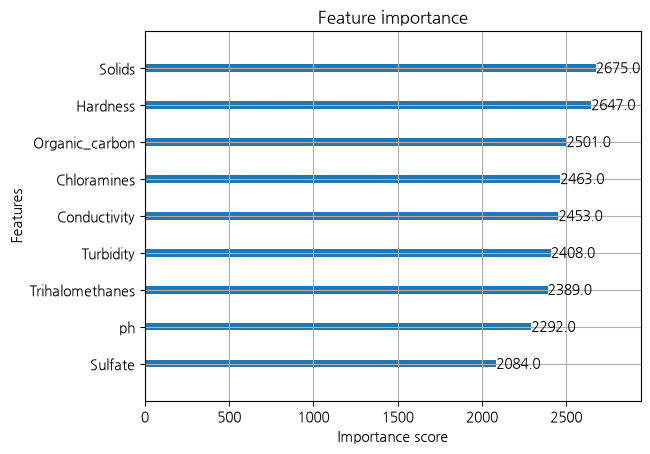

In [74]:
plot_importance(grid_cv.best_estimator_)
pyplot.show()

findfont: Failed to find font weight bold, now using 600.
findfont: Failed to find font weight bold, now using 600.


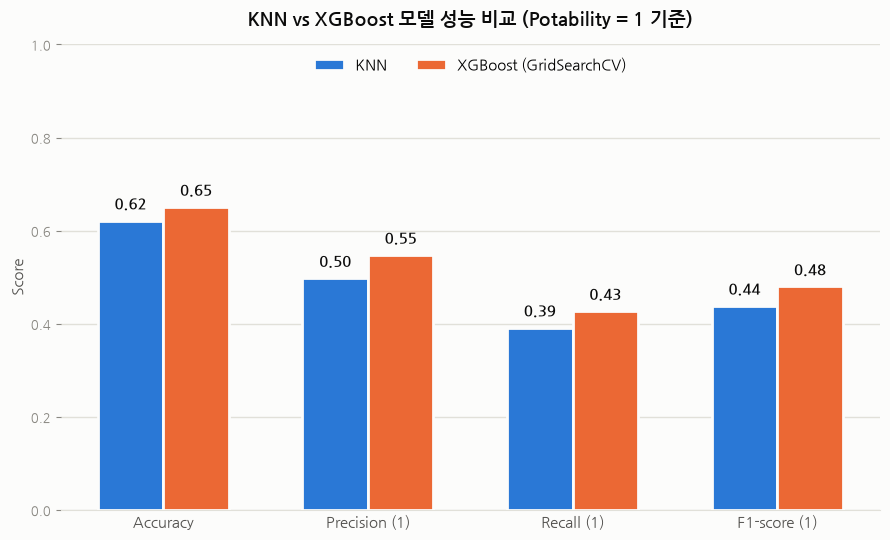

In [65]:
# KNN vs XGBoost 성능 비교 시각화 (Potability=1 기준 지표)

def get_metrics(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (1)': report['1']['precision'],
        'Recall (1)': report['1']['recall'],
        'F1-score (1)': report['1']['f1-score'],
    }

knn_metrics = get_metrics(y_test, y_pred_knn)
xgb_metrics = get_metrics(y_test, y_pred_xgb)

metric_names = list(knn_metrics.keys())
knn_values = list(knn_metrics.values())
xgb_values = list(xgb_metrics.values())

# 카테고리 색상 (고정 순서: KNN=blue, XGBoost=orange)
COLOR_KNN = '#2a78d6'
COLOR_XGB = '#eb6834'
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

x = np.arange(len(metric_names))
width = 0.32

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

bars_knn = ax.bar(x - width/2, knn_values, width, label='KNN',
                   color=COLOR_KNN, edgecolor=SURFACE, linewidth=2, zorder=3)
bars_xgb = ax.bar(x + width/2, xgb_values, width, label='XGBoost (GridSearchCV)',
                   color=COLOR_XGB, edgecolor=SURFACE, linewidth=2, zorder=3)

for bars in (bars_knn, bars_xgb):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f'{h:.2f}',
                ha='center', va='bottom', fontsize=10.5, color=INK_PRIMARY, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11, color=INK_SECONDARY)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score', fontsize=11, color=INK_SECONDARY)
ax.set_title('KNN vs XGBoost 모델 성능 비교 (Potability = 1 기준)',
             fontsize=13.5, color=INK_PRIMARY, fontweight='bold', pad=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color(GRID)

ax.yaxis.grid(True, color=GRID, linewidth=1, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis='y', colors=INK_MUTED, labelsize=9.5)
ax.tick_params(axis='x', length=0)

ax.legend(frameon=False, fontsize=10.5, loc='upper center', ncol=2)

plt.tight_layout()
plt.show()

### 음수 분류에 대한 best model 저장하기

> KNN, XGBoost 모델 중에는 사용자 여유가 있다면 가장 최적의 파라미터 값을 갖춘 XGBoost 모델을 사용하는 것이 더 적합할 것으로 판단하여 해당 모델 저장을 진행하겠다.

*gridsearchcv 의 grid_cv 객체의 refit 이 default = True 로 가장 최적의 파라미터 값을 저장하기에 가능*

In [63]:
import joblib

In [64]:
joblib.dump(grid_cv, "potability_best_model.pkl")

['potability_best_model.pkl']